In [31]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import DataLoader, Subset, random_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import time
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [25]:
transform = transforms.Compose([
    # transforms.Resize((224, 224)), 
    transforms.Grayscale(3),       
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [26]:
train_dataset = torchvision.datasets.MNIST(root='./dataset_q3', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./dataset_q3', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

In [27]:
class CNN_MNIST(nn.Module):
    def __init__(self):
        super(CNN_MNIST, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 14 * 14, 128)
        self.fc2 = nn.Linear(128, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [39]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs, patience=5):
    best_val_loss = float('inf')
    epochs_no_improve = 0

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)

        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), './cnn_model.pth')
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"\n⛔ Early stopping triggered at epoch {epoch+1}")
            break


In [33]:
cnn_model = CNN_MNIST().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(),lr=0.001)

train_size = 54000
val_size = len(train_dataset) - train_size

train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=1000, shuffle=False)

In [40]:
train_model(cnn_model,train_loader,val_loader,criterion,optimizer,30)

Epoch [1/30] | Train Loss: 0.0077 | Val Loss: 0.0715
Epoch [2/30] | Train Loss: 0.0053 | Val Loss: 0.0829
Epoch [3/30] | Train Loss: 0.0056 | Val Loss: 0.0782
Epoch [4/30] | Train Loss: 0.0063 | Val Loss: 0.0976
Epoch [5/30] | Train Loss: 0.0035 | Val Loss: 0.0910
Epoch [6/30] | Train Loss: 0.0040 | Val Loss: 0.0960

⛔ Early stopping triggered at epoch 6


In [41]:
torch.save(cnn_model.state_dict(),'./cnnmodel.pth')

In [43]:
cnn_model.eval()
y_pred = []
y_label = []
t_start = time.time()
with torch.no_grad():
    for img, label in test_loader:
        img = img.to(device)
        label = label.to(device)

        # no flattening here!
        output = cnn_model(img)

        # get predicted class
        prediction = torch.argmax(output, dim=1)

        y_pred.append(prediction.cpu().numpy())
        y_label.append(label.cpu().numpy())

t_end = time.time()
# combine all batches
y_pred = np.concatenate(y_pred)
y_label = np.concatenate(y_label)

print(f"Shape of y_pred = {y_pred.shape}")
print(f"Shape of y_label = {y_label.shape}")


Shape of y_pred = (10000,)
Shape of y_label = (10000,)


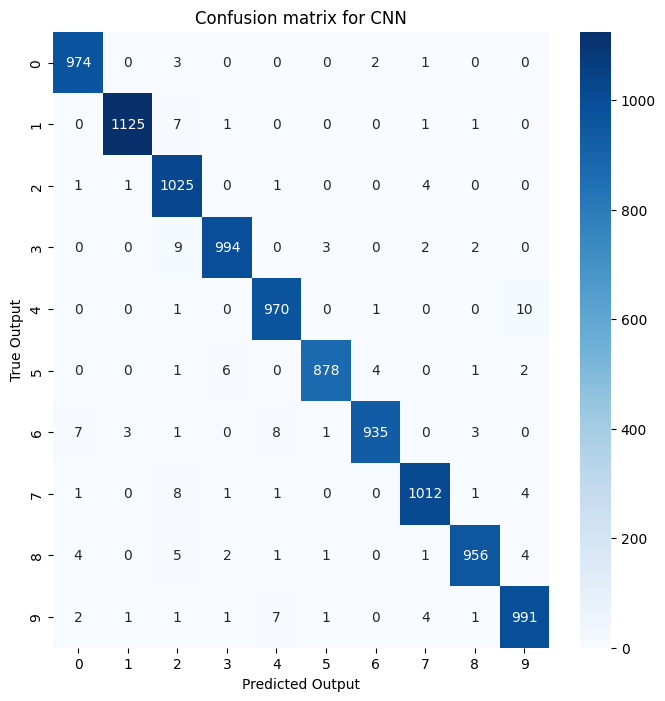

Accuracy for CNN = 98.6
F1 score for CNN = 0.9859626578925246
The Inference time needed for CNN model is 5.4740705490112305s
Total number of parameters: 805130


In [46]:
accuracy_cnn = ((y_pred == y_label).sum())/100
f1_cnn = f1_score(y_label,y_pred,average = "macro")
cm_cnn = confusion_matrix(y_label,y_pred)

plt.figure(figsize=(8,8))
sns.heatmap(cm_cnn,annot=True,fmt="d",cmap="Blues", xticklabels= np.unique(y_label),
        yticklabels= np.unique(y_label))
plt.xlabel("Predicted Output")
plt.ylabel("True Output")
plt.title("Confusion matrix for CNN")
plt.show()
print(f"Accuracy for CNN = {accuracy_cnn}")
print(f"F1 score for CNN = {f1_cnn}")
print(f"The Inference time needed for CNN model is {t_end - t_start}s")

total_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f'Total number of parameters: {total_params}')

Using other models

In [47]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),     # required for pretrained CNNs
    transforms.Grayscale(num_output_channels=3),  # convert 1→3 channels
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [57]:
train_dataset = torchvision.datasets.MNIST(root='./dataset_q3', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.MNIST(root='./dataset_q3', train=False, transform=transform, download=True)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1000, shuffle=False)


In [58]:
mobilenet_model = models.mobilenet_v2(pretrained = True)

mobilenet_params = sum(p.numel() for p in mobilenet_model.parameters() if p.requires_grad)

c:\Users\PRANEEL JOSHI\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\PRANEEL JOSHI\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [59]:
for p in mobilenet_model.features.parameters():
    p.requires_grad = False

mobilenet_model.classifier[1] = nn.Linear(mobilenet_model.last_channel,10)

mobilenet_model = mobilenet_model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer_mobilenet = torch.optim.Adam(mobilenet_model.parameters(),lr = 1e-3)

In [60]:
train_model(mobilenet_model, train_loader, val_loader, criterion, optimizer_mobilenet, epochs=10)


Epoch [1/10] | Train Loss: 0.3551 | Val Loss: 5.3583
Epoch [2/10] | Train Loss: 0.2490 | Val Loss: 5.7833
Epoch [3/10] | Train Loss: 0.2362 | Val Loss: 6.1929
Epoch [4/10] | Train Loss: 0.2288 | Val Loss: 5.4707
Epoch [5/10] | Train Loss: 0.2289 | Val Loss: 6.3398
Epoch [6/10] | Train Loss: 0.2294 | Val Loss: 6.7907

⛔ Early stopping triggered at epoch 6


In [61]:
mobilenet_model.eval()
y_pred = []
y_label = []
t_start_mb = time.time()
with torch.no_grad():
    for img, label in test_loader:
        img = img.to(device)
        label = label.to(device)

        # no flattening here!
        output = mobilenet_model(img)

        # get predicted class
        prediction = torch.argmax(output, dim=1)

        y_pred.append(prediction.cpu().numpy())
        y_label.append(label.cpu().numpy())

t_end_mb = time.time()
# combine all batches
y_pred = np.concatenate(y_pred)
y_label = np.concatenate(y_label)



OutOfMemoryError: CUDA out of memory. Tried to allocate 1.50 GiB. GPU 0 has a total capacity of 4.00 GiB of which 0 bytes is free. Of the allocated memory 9.24 GiB is allocated by PyTorch, and 365.60 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
accuracy_mb = ((y_pred == y_label).sum())/100
f1_mb = f1_score(y_label,y_pred,average = "macro")
cm_mb = confusion_matrix(y_label,y_pred)

plt.figure(figsize=(8,8))
sns.heatmap(cm_mb,annot=True,fmt="d",cmap="Blues", xticklabels= np.unique(y_label),
        yticklabels= np.unique(y_label))
plt.xlabel("Predicted Output")
plt.ylabel("True Output")
plt.title("Confusion matrix for Mobilenet")
plt.show()
print(f"Accuracy for Mobilenet = {accuracy_mb}")
print(f"F1 score for Mobilenet = {f1_mb}")
print(f"The Inference time needed for Mobilenet model is {t_end_mb - t_start_mb}s")


print(f'Total number of parameters: {mobilenet_params}')

In [ ]:
efficientnet_model = models.efficientnet_b0(pretrained = True)

efficientnet_params = sum(p.numel() for p in mobilenet_model.parameters() if p.requires_grad)

In [ ]:
for p in efficientnet_model.features.parameters():
    p.requires_grad = False

efficientnet_model.classifier[1] = nn.Linear(efficientnet_model.last_channel,10)

efficientnet_model = efficientnet_model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer_efficientnet = torch.optim.Adam(efficientnet_model.parameters(),lr = 1e-3)

In [ ]:
train_model(efficientnet_model, train_loader, val_loader, criterion, optimizer_mobilenet, epochs=10)


In [ ]:
efficientnet_model.eval()
y_pred = []
y_label = []
t_start_eff = time.time()
with torch.no_grad():
    for img, label in test_loader:
        img = img.to(device)
        label = label.to(device)

        # no flattening here!
        output = efficientnet_model(img)

        # get predicted class
        prediction = torch.argmax(output, dim=1)

        y_pred.append(prediction.cpu().numpy())
        y_label.append(label.cpu().numpy())

t_end_eff = time.time()
# combine all batches
y_pred = np.concatenate(y_pred)
y_label = np.concatenate(y_label)


In [ ]:
accuracy_eff = ((y_pred == y_label).sum())/100
f1_eff = f1_score(y_label,y_pred,average = "macro")
cm_eff = confusion_matrix(y_label,y_pred)

plt.figure(figsize=(8,8))
sns.heatmap(cm_eff,annot=True,fmt="d",cmap="Blues", xticklabels= np.unique(y_label),
        yticklabels= np.unique(y_label))
plt.xlabel("Predicted Output")
plt.ylabel("True Output")
plt.title("Confusion matrix for Mobilenet")
plt.show()
print(f"Accuracy for Efficientnet = {accuracy_eff}")
print(f"F1 score for Efficientnet = {f1_eff}")
print(f"The Inference time needed for Mobilenet model is {t_end_eff - t_start_eff}s")


print(f'Total number of parameters: {efficientnet_params}')